# Getting Started: ADAPT-VQE for H3+

This notebook runs a minimal **ADAPT-VQE** workflow for the molecular ion
**H3+**.

Goals:

- run a small ADAPT-VQE calculation
- inspect the adaptive ansatz growth
- compare the final energy against the exact ground-state energy
- compare ADAPT-VQE with a fixed-ansatz VQE run

This is the basic adaptive-ansatz workflow in the repository.

In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from common.hamiltonian import get_exact_spectrum
from vqe.adapt import run_adapt_vqe
from vqe.core import run_vqe

## Why ADAPT-VQE?

In standard VQE, we choose a fixed ansatz up front and optimize its
parameters.

In **ADAPT-VQE**, the ansatz is grown iteratively:

1. start from the Hartree-Fock reference
2. score operators from a pool by gradient magnitude
3. append the best operator
4. re-optimize
5. repeat until the gradient falls below a tolerance or a maximum size is hit

This makes ADAPT-VQE a useful workflow when we want a more problem-adapted
circuit.

## Exact reference spectrum

For a small system like `H3+`, we can compare the final ADAPT-VQE energy
against the exact ground-state value.

In [2]:
exact_spectrum = np.asarray(get_exact_spectrum("H3+"), dtype=float)
exact_spectrum = np.sort(exact_spectrum)

exact_ground_energy = float(exact_spectrum[0])

print("Lowest exact energies:")
print(exact_spectrum[:6])
print()
print(f"Exact ground-state energy: {exact_ground_energy:.10f}")

Lowest exact energies:
[-1.29605528 -1.29605528 -1.29588923 -1.29588923 -1.26173679 -0.82051506]

Exact ground-state energy: -1.2960552774


## Run a minimal ADAPT-VQE calculation

We use:

- molecule: `H3+`
- pool: `uccs`
- a modest operator budget
- a small gradient tolerance

The `uccs` pool keeps the example lighter while still showing the adaptive
workflow clearly.

In [3]:
adapt_res = run_adapt_vqe(
    molecule="H3+",
    pool="uccsd",
    max_ops=12,
    grad_tol=1e-4,
    inner_steps=40,
    inner_stepsize=0.15,
    optimizer_name="Adam",
    seed=0,
    mapping="jordan_wigner",
    noisy=False,
    plot=False,
    force=True,
)


💾 Saved ADAPT-VQE run record: results/vqe/H3plus_adaptminusvqe_uccsd_adam_noiseless_s0_0b10f7f7fe4d_adapt.json



In [4]:
sorted(adapt_res.keys())

['config',
 'energies',
 'energy',
 'final_params',
 'inner_energies',
 'max_gradients',
 'num_qubits',
 'selected_operators']

## Main returned quantities

In [5]:
adapt_final_energy = float(adapt_res["energy"])
adapt_outer_energies = np.asarray(adapt_res["energies"], dtype=float)
adapt_max_gradients = np.asarray(adapt_res["max_gradients"], dtype=float)
adapt_inner_energies = adapt_res["inner_energies"]
adapt_selected_ops = adapt_res["selected_operators"]
adapt_final_params = np.asarray(adapt_res["final_params"], dtype=float)
adapt_num_qubits = int(adapt_res["num_qubits"])

print(f"ADAPT-VQE final energy : {adapt_final_energy:.10f}")
print(f"Number of qubits       : {adapt_num_qubits}")
print(f"Selected operators     : {len(adapt_selected_ops)}")
print(f"Final parameter count  : {len(adapt_final_params)}")

ADAPT-VQE final energy : -1.2960233357
Number of qubits       : 6
Selected operators     : 4
Final parameter count  : 4


## Compare against the exact ground-state energy

In [6]:
adapt_abs_error = abs(adapt_final_energy - exact_ground_energy)

print(f"ADAPT-VQE final energy : {adapt_final_energy:.10f}")
print(f"Exact ground energy    : {exact_ground_energy:.10f}")
print(f"Absolute error         : {adapt_abs_error:.6e}")

ADAPT-VQE final energy : -1.2960233357
Exact ground energy    : -1.2960552774
Absolute error         : 3.194169e-05


## Selected operator sequence

ADAPT-VQE returns the operators chosen during ansatz growth.

In [7]:
for i, op in enumerate(adapt_selected_ops, start=1):
    kind = op.get("kind", "unknown")
    wires = op.get("wires", [])
    print(f"{i:2d}. kind={kind:>6s}   wires={wires}")

 1. kind=double   wires=[0, 1, 4, 5]
 2. kind=double   wires=[1, 2, 3, 4]
 3. kind=single   wires=[1, 5]
 4. kind=single   wires=[0, 4]


## Outer-loop energy trajectory

The outer-loop energy is the energy after each adaptive grow-and-optimize step.

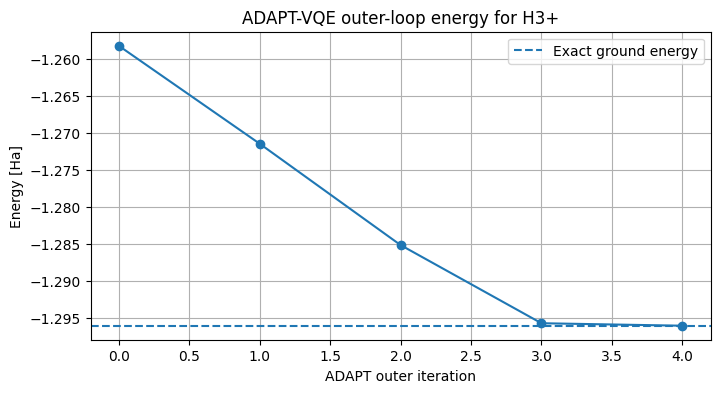

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(adapt_outer_energies)), adapt_outer_energies, marker="o")
plt.axhline(exact_ground_energy, linestyle="--", label="Exact ground energy")
plt.xlabel("ADAPT outer iteration")
plt.ylabel("Energy [Ha]")
plt.title("ADAPT-VQE outer-loop energy for H3+")
plt.grid(True)
plt.legend()
plt.show()

## Gradient magnitudes

The maximum pool gradient at each outer iteration is the quantity used to
decide whether another operator should be appended.

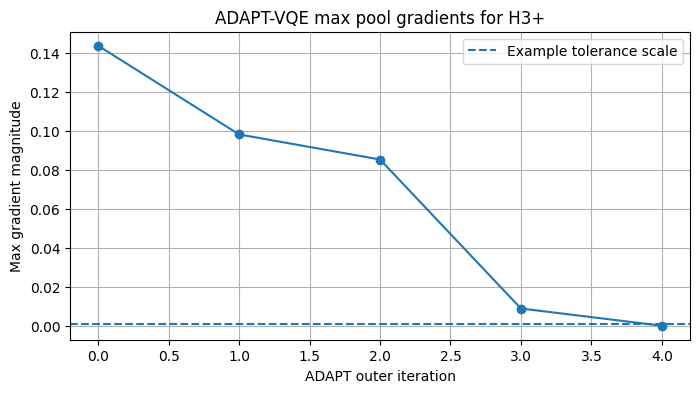

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(adapt_max_gradients)), adapt_max_gradients, marker="o")
plt.axhline(1e-3, linestyle="--", label="Example tolerance scale")
plt.xlabel("ADAPT outer iteration")
plt.ylabel("Max gradient magnitude")
plt.title("ADAPT-VQE max pool gradients for H3+")
plt.grid(True)
plt.legend()
plt.show()

## Inner optimization traces

Each outer ADAPT step contains an inner optimization over the current ansatz.
Plotting those traces shows how the optimization behaves as the ansatz grows.

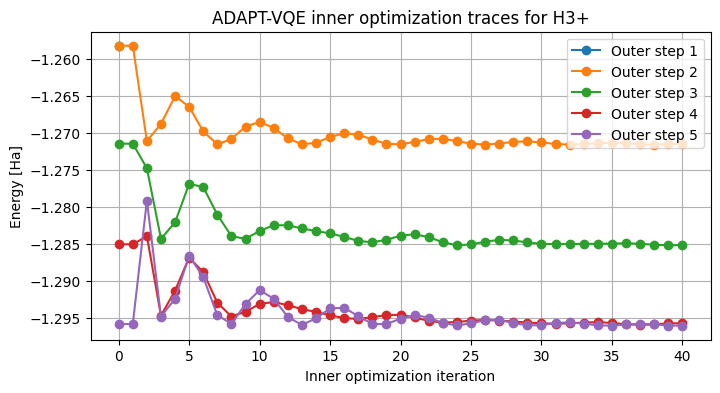

In [10]:
plt.figure(figsize=(8, 4))
for i, trace in enumerate(adapt_inner_energies, start=1):
    trace = np.asarray(trace, dtype=float)
    plt.plot(np.arange(len(trace)), trace, marker="o", label=f"Outer step {i}")

plt.xlabel("Inner optimization iteration")
plt.ylabel("Energy [Ha]")
plt.title("ADAPT-VQE inner optimization traces for H3+")
plt.grid(True)
plt.legend()
plt.show()

## Compare with fixed-ansatz VQE

ADAPT-VQE is easiest to interpret when compared with a standard VQE run on the
same molecule.

In [11]:
vqe_res = run_vqe(
    molecule="H3+",
    ansatz_name="UCCSD",
    optimizer_name="Adam",
    steps=80,
    stepsize=0.2,
    seed=0,
    noisy=False,
    force=True,
    plot=False,
)

Step 01/80: E = -1.258232 Ha
Step 02/80: E = -1.287185 Ha
Step 03/80: E = -1.284938 Ha
Step 04/80: E = -1.256240 Ha
Step 05/80: E = -1.278331 Ha
Step 06/80: E = -1.282361 Ha
Step 07/80: E = -1.284300 Ha
Step 08/80: E = -1.287456 Ha
Step 09/80: E = -1.285328 Ha
Step 10/80: E = -1.281099 Ha
Step 11/80: E = -1.283090 Ha
Step 12/80: E = -1.289688 Ha
Step 13/80: E = -1.293663 Ha
Step 14/80: E = -1.292250 Ha
Step 15/80: E = -1.288838 Ha
Step 16/80: E = -1.288139 Ha
Step 17/80: E = -1.290730 Ha
Step 18/80: E = -1.293322 Ha
Step 19/80: E = -1.293735 Ha
Step 20/80: E = -1.293078 Ha
Step 21/80: E = -1.292838 Ha
Step 22/80: E = -1.292959 Ha
Step 23/80: E = -1.293085 Ha
Step 24/80: E = -1.293467 Ha
Step 25/80: E = -1.294320 Ha
Step 26/80: E = -1.295109 Ha
Step 27/80: E = -1.295065 Ha
Step 28/80: E = -1.294296 Ha
Step 29/80: E = -1.293822 Ha
Step 30/80: E = -1.294325 Ha
Step 31/80: E = -1.295320 Ha
Step 32/80: E = -1.295807 Ha
Step 33/80: E = -1.295486 Ha
Step 34/80: E = -1.294975 Ha
Step 35/80: E 

In [12]:
vqe_final_energy = float(vqe_res["energy"])
vqe_energies = np.asarray(vqe_res["energies"], dtype=float)
vqe_abs_error = abs(vqe_final_energy - exact_ground_energy)

print(f"Fixed UCCSD VQE final energy : {vqe_final_energy:.10f}")
print(f"Fixed UCCSD absolute error   : {vqe_abs_error:.6e}")

Fixed UCCSD VQE final energy : -1.2960435062
Fixed UCCSD absolute error   : 1.177123e-05


## Final-energy comparison

In [13]:
print(f"{'Method':<18} {'Final energy':>18} {'|ΔE| vs exact':>18}")
print("-" * 56)
print(f"{'ADAPT-VQE':<18} {adapt_final_energy:>18.10f} {adapt_abs_error:>18.6e}")
print(f"{'VQE (UCCSD)':<18} {vqe_final_energy:>18.10f} {vqe_abs_error:>18.6e}")

Method                   Final energy      |ΔE| vs exact
--------------------------------------------------------
ADAPT-VQE               -1.2960233357       3.194169e-05
VQE (UCCSD)             -1.2960435062       1.177123e-05


## Energy-trace comparison

The x-axes represent different notions of iteration:

- VQE: optimizer iterations for a fixed ansatz
- ADAPT-VQE: outer ansatz-growth iterations

So this plot is qualitative rather than one-to-one.

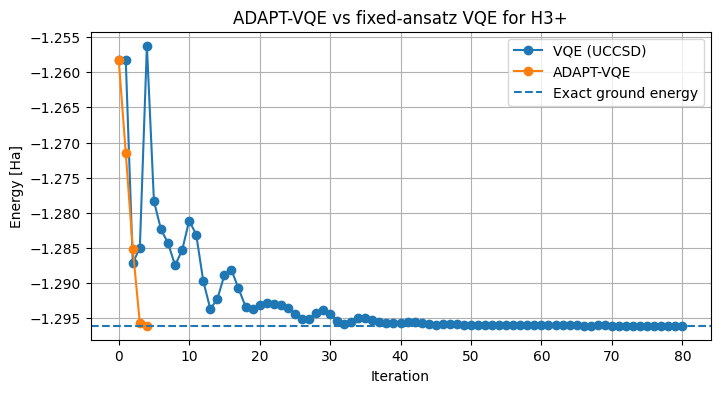

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(vqe_energies)), vqe_energies, marker="o", label="VQE (UCCSD)")
plt.plot(np.arange(len(adapt_outer_energies)), adapt_outer_energies, marker="o", label="ADAPT-VQE")
plt.axhline(exact_ground_energy, linestyle="--", label="Exact ground energy")
plt.xlabel("Iteration")
plt.ylabel("Energy [Ha]")
plt.title("ADAPT-VQE vs fixed-ansatz VQE for H3+")
plt.grid(True)
plt.legend()
plt.show()

## Ansatz size growth

In ADAPT-VQE, the ansatz size is itself an output of the algorithm.

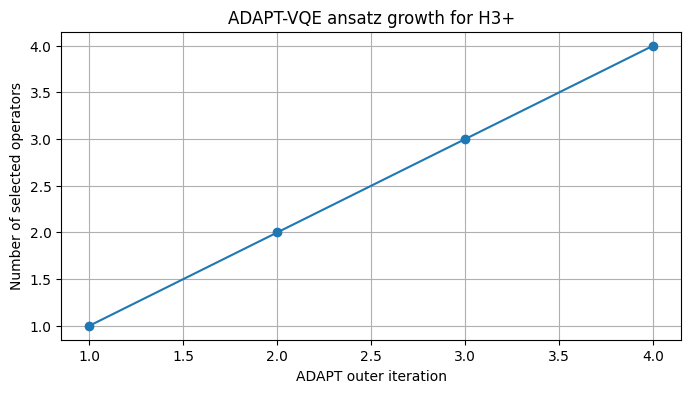

In [15]:
ansatz_sizes = np.arange(1, len(adapt_selected_ops) + 1)

plt.figure(figsize=(8, 4))
plt.plot(ansatz_sizes, ansatz_sizes, marker="o")
plt.xlabel("ADAPT outer iteration")
plt.ylabel("Number of selected operators")
plt.title("ADAPT-VQE ansatz growth for H3+")
plt.grid(True)
plt.show()

## Interpretation

A useful way to contrast the two workflows is:

- **VQE** chooses the circuit structure first, then optimizes parameters
- **ADAPT-VQE** grows the circuit structure during the optimization loop

This makes ADAPT-VQE attractive when a compact, chemistry-informed ansatz is
preferred over a larger fixed ansatz.

## What this notebook showed

We:

- ran a minimal `ADAPT-VQE` workflow for `H3+`
- inspected the adaptive operator sequence
- plotted outer and inner optimization traces
- compared the final energy with the exact ground-state reference
- compared `ADAPT-VQE` with a fixed `UCCSD` VQE run

This is the basic adaptive-ansatz workflow in the repository.